In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Lambda, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import losses
from tensorflow.keras import ops
from scipy.stats import norm

I0000 00:00:1787663152.403132   34676 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787663152.437022   34676 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787663153.434879   34676 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787663153.435120   34676 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU

In [12]:
# Load data – training and test
(x_tr, y_tr), (x_te, y_te) = mnist.load_data()

In [13]:
#Normalize and Reshape images (flatten)
x_tr, x_te = x_tr.astype('float32')/255., x_te.astype('float32')/255.
x_tr_flat, x_te_flat = x_tr.reshape(x_tr.shape[0], -1), x_te.reshape(x_te.shape[0], -1)

In [14]:
print(x_tr.shape, x_te.shape)
print(x_tr_flat.shape, x_te_flat.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 784) (10000, 784)


In [15]:
# Neural Network Parameters
batch_size, n_epoch = 100, 50
n_hidden, z_dim = 256, 2

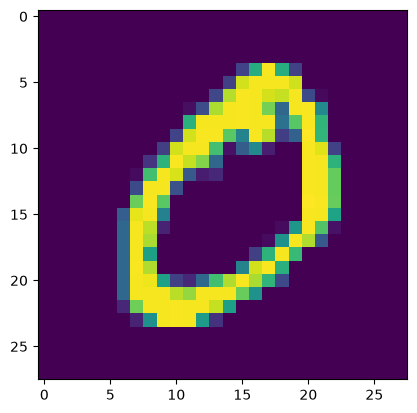

In [7]:
# Example of a training image
plt.imshow(x_tr[1]);

In [16]:
# sampling function corregida para Keras 3
def sampling(args):
    mu, log_var = args
    # Usamos tf.random.normal asegurando el batch_size y z_dim de forma dinámica
    batch_size_dim = tf.shape(mu)[0]
    eps = tf.random.normal(shape=(batch_size_dim, z_dim), mean=0., stddev=1.0)
    return mu + ops.exp(log_var) * eps

In [17]:
# Capa personalizada para calcular e inyectar la pérdida KL de forma nativa en Keras 3
class KLLossLayer(Layer):
    def call(self, inputs):
        mu, log_var = inputs
        kl = -0.5 * ops.sum(1 + log_var - ops.square(mu) - ops.exp(log_var), axis=-1)
        self.add_loss(ops.mean(kl))
        return mu

# Encoder - from 784->256->128->2
inputs_flat = Input(shape=(x_tr_flat.shape[1],))
x_flat = Dense(n_hidden, activation='relu')(inputs_flat) # first hidden layer
x_flat = Dense(n_hidden//2, activation='relu')(x_flat)  # second hidden layer

# hidden state
mu_flat = Dense(z_dim)(x_flat)
log_var_flat = Dense(z_dim)(x_flat)

# Aplicamos la capa que calcula la KL loss internamente y devuelve mu para el sampling
mu_kl_checked = KLLossLayer()([mu_flat, log_var_flat])

# Usamos mu_kl_checked (o mu_flat y log_var_flat) en la capa Lambda
z_flat = Lambda(sampling, output_shape=(z_dim,))([mu_flat, log_var_flat])

E0000 00:00:1787663167.139951   34676 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
#Decoder - from 2->128->256->784
latent_inputs = Input(shape=(z_dim,))
z_decoder1 = Dense(n_hidden//2, activation='relu')
z_decoder2 = Dense(n_hidden, activation='relu')
y_decoder = Dense(x_tr_flat.shape[1], activation='sigmoid')
z_decoded = z_decoder1(latent_inputs)
z_decoded = z_decoder2(z_decoded)
y_decoded = y_decoder(z_decoded)
decoder_flat = Model(latent_inputs, y_decoded, name="decoder_conv")

outputs_flat = decoder_flat(z_flat)

In [19]:

def vae_loss_function(y_true, y_pred):
    # 1. Pérdida de reconstrucción
    rec_loss = losses.binary_crossentropy(y_true, y_pred) * x_tr_flat.shape[1]
    
    # 2. Divergencia KL (usando las variables globales mu_flat y log_var_flat de tu entorno)
    kl = -0.5 * ops.sum(1 + log_var_flat - ops.square(mu_flat) - ops.exp(log_var_flat), axis=-1)
    
    return rec_loss + kl

# Compilamos el modelo funcional estándar sin usar add_loss()
vae_flat = Model(inputs_flat, outputs_flat)
vae_flat.compile(optimizer='adam', loss=vae_loss_function)

In [20]:
# Build model
vae_flat = Model(inputs_flat, outputs_flat)

# Compilamos únicamente con la pérdida de reconstrucción (la KL ya va por dentro con add_loss)
vae_flat.compile(optimizer='adam', loss=losses.binary_crossentropy)

In [24]:
# train
vae_flat.fit(
    x=x_tr_flat,
    y=x_tr_flat,
    shuffle=True,
    epochs=n_epoch,
    batch_size=batch_size,
    validation_data=(x_te_flat, x_te_flat),
    verbose=1
)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1659 - val_loss: 0.1681
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1659 - val_loss: 0.1683
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1654 - val_loss: 0.1683
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1652 - val_loss: 0.1679
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1650 - val_loss: 0.1675
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1648 - val_loss: 0.1679
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1646 - val_loss: 0.1674
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1645 - val_loss: 0.1672
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1642 - val_loss: 0.1674
Epoch 10/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1640 - val_loss: 0.1677
Epoch 11/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1637 - val_loss: 0.1672
Epoch 12/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

Visualize Embeddings

In [25]:
# Build encoders
encoder_f = Model(inputs_flat, z_flat)  # flat encoder

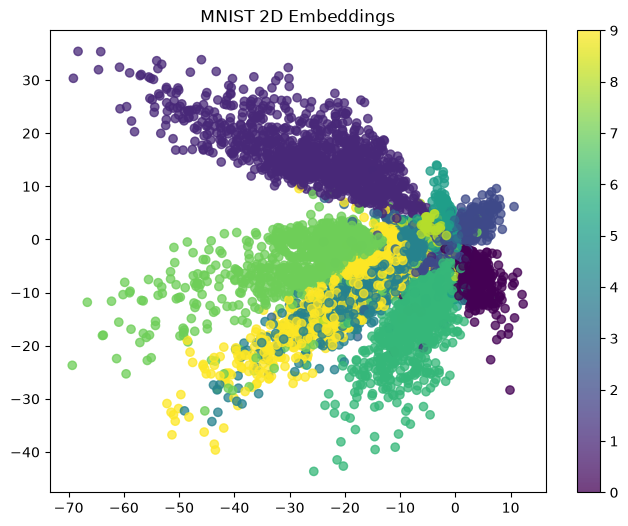

In [26]:
# Plot of the digit classes in the latent space
x_te_latent = encoder_f.predict(x_te_flat, batch_size=batch_size,verbose=0)
plt.figure(figsize=(8, 6))
plt.scatter(x_te_latent[:, 0], x_te_latent[:, 1], c=y_te, alpha=0.75)
plt.title('MNIST 2D Embeddings')
plt.colorbar()
plt.show()

Example: compare three embeddings

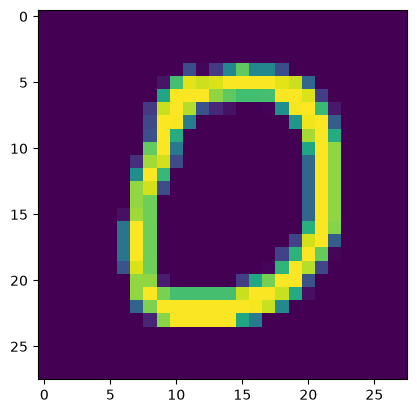

In [27]:
plt.imshow(x_te_flat[10].reshape(28,28));

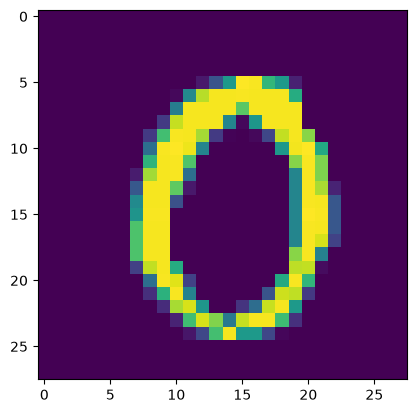

In [28]:
plt.imshow(x_te_flat[13].reshape(28,28));

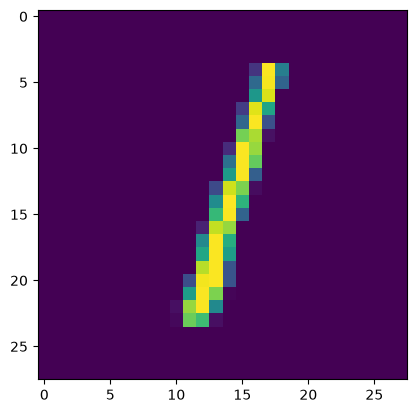

In [29]:
plt.imshow(x_te_flat[2].reshape(28,28));

In [30]:
# calculate vectors for each digit
zero_A = x_te_latent[10]
zero_B = x_te_latent[13]
one = x_te_latent[2]

print(f"Embedding for the first ZERO is  {zero_A}")
print(f"Embedding for the second ZERO is {zero_B}")
print(f"Embedding for the ONE is         {one}")

Embedding for the first ZERO is  [ 1.7340168 -3.09939  ]
Embedding for the second ZERO is [ 1.2699562 -2.69521  ]
Embedding for the ONE is         [-32.26135   23.487068]


Using more advanced models based on the Transformer architechture you can embed sentences aswell.

In [31]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9754.42it/s]


In [32]:
#Sentences we want to encode. Example:
sentence = ['The team enjoyed the hike through the meadow',
            'The national park had great views',
            'Olive oil drizzled over pizza tastes delicious']

In [33]:
#Sentences are encoded by calling model.encode()
embedding = model.encode(sentence)

#Preview the embeddings
print(embedding)

[[ 0.3706196   0.26414266  0.21265697 ...  0.14994566 -0.2579493
  -0.23970763]
 [ 0.6693331   0.40094948 -0.48208404 ...  0.10645872 -1.5067163
  -0.0154734 ]
 [-0.26555917  0.11172415 -0.14733034 ...  0.42197478  0.88394576
   0.10763917]]


In [34]:
embedding.shape

(3, 384)

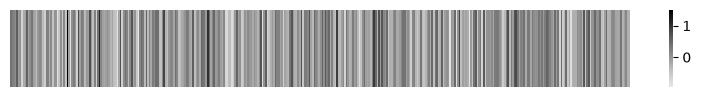

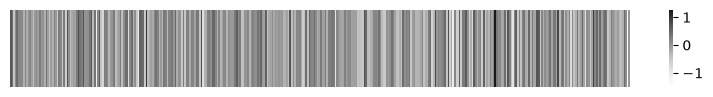

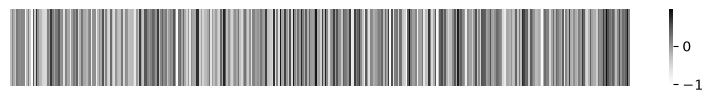

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(embedding[0].reshape(-1,384),cmap="Greys",center=0,square=False)
plt.gcf().set_size_inches(10,1)
plt.axis('off')
plt.show()

sns.heatmap(embedding[1].reshape(-1,384),cmap="Greys",center=0,square=False)
plt.gcf().set_size_inches(10,1)
plt.axis('off')
plt.show()

sns.heatmap(embedding[2].reshape(-1,384),cmap="Greys",center=0,square=False)
plt.gcf().set_size_inches(10,1)
plt.axis('off')
plt.show()

How can we measure the distance between these Image and Sentence Embeddings?
There are many ways to calculate the distances between two vectors.

Here we will cover 4 distance metrics that you might find being used in the context of vector databases:

Euclidean Distance(L2) - The length of the shortest path between two points or vectors.
Manhattan Distance(L1) - Distance between two points if one was constrained to move only along one axis at a time.
Dot Product - Measures the magnitude of the projection of one vector onto the other.
Cosine Distance - Measure the difference in directionality between vectors.

In [36]:
# Euclidean Distance
zero_A = x_te_latent[10]
zero_B = x_te_latent[13]
L2 = [(zero_A[i] - zero_B[i])**2 for i in range(len(zero_A))]
L2 = np.sqrt(np.array(L2).sum())
print(L2)

0.6153972


In [37]:
#An alternative way of doing this
np.linalg.norm((zero_A - zero_B), ord=2)

np.float32(0.6153972)

In [38]:
#Calculate L2 distances
print("Distance zeroA-zeroB:", np.linalg.norm((zero_A - zero_B), ord=2))
print("Distance zeroA-one:  ", np.linalg.norm((zero_A - one), ord=2))
print("Distance zeroB-one:  ", np.linalg.norm((zero_B - one), ord=2))

Distance zeroA-zeroB: 0.6153972
Distance zeroA-one:   43.15698
Distance zeroB-one:   42.542446


In [39]:
# Manhattan Distance
L1 = [zero_A[i] - zero_B[i] for i in range(len(zero_A))]
L1 = np.abs(L1).sum()

print(L1)

0.8682406


In [40]:
#an alternative way of doing this is
np.linalg.norm((zero_A - zero_B), ord=1)

np.float32(0.8682406)

In [41]:
#Calculate L1 distances
print("Distance zeroA-zeroB:", np.linalg.norm((zero_A - zero_B), ord=1))
print("Distance zeroA-one:  ", np.linalg.norm((zero_A - one), ord=1))
print("Distance zeroB-one:  ", np.linalg.norm((zero_B - one), ord=1))

Distance zeroA-zeroB: 0.8682406
Distance zeroA-one:   60.581825
Distance zeroB-one:   59.71358


In [42]:
# Dot Product
np.dot(zero_A,zero_B)

np.float32(10.555633)

In [43]:
#Calculate Dot products
print("Distance zeroA-zeroB:", np.dot(zero_A, zero_B))
print("Distance zeroA-one:  ", np.dot(zero_A, one))
print("Distance zeroB-one:  ", np.dot(zero_B, one))

Distance zeroA-zeroB: 10.555633
Distance zeroA-one:   -128.7373
Distance zeroB-one:   -104.27309


In [44]:
# Cosine Distance
cosine = 1 - np.dot(zero_A,zero_B)/(np.linalg.norm(zero_A)*np.linalg.norm(zero_B))
print(f"{cosine:.6f}")

0.002432


In [45]:
zero_A/zero_B

array([1.3654146, 1.1499623], dtype=float32)

In [46]:
# Cosine Distance function
def cosine_distance(vec1,vec2):
  cosine = 1 - (np.dot(vec1, vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2)))
  return cosine

In [47]:
#Cosine Distance
print(f"Distance zeroA-zeroB: {cosine_distance(zero_A, zero_B): .6f}")
print(f"Distance zeroA-one:   {cosine_distance(zero_A, one): .6f}")
print(f"Distance zeroB-one:   {cosine_distance(zero_B, one): .6f}")

Distance zeroA-zeroB:  0.002432
Distance zeroA-one:    1.908372
Distance zeroB-one:    1.877020


Now with the sentence embeddings!
Dot Product and Cosine Distance are commonly used in the field of NLP, to evaluate how similar two sentence embeddings are. So here we will only use those two.

embedding0 - 'The team enjoyed the hike through the meadow'

embedding1 - The national park had great views'

embedding2 - 'Olive oil drizzled over pizza tastes delicious'

In [48]:
#Dot Product
print("Distance 0-1:", np.dot(embedding[0], embedding[1]))
print("Distance 0-2:", np.dot(embedding[0], embedding[2]))
print("Distance 1-2:", np.dot(embedding[1], embedding[2]))

Distance 0-1: 26.497883
Distance 0-2: 2.078575
Distance 1-2: 4.01921


In [49]:
#Cosine Distance
print("Distance 0-1: ", cosine_distance(embedding[0], embedding[1]))
print("Distance 0-2: ", cosine_distance(embedding[0], embedding[2]))
print("Distance 1-2: ", cosine_distance(embedding[1], embedding[2]))

Distance 0-1:  0.5350337
Distance 0-2:  0.96393937
Distance 1-2:  0.92887914
